<a href="https://colab.research.google.com/github/adhikaryramen87/MachineLearning_Works/blob/main/Normalization_in_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import all the required libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

Load and preprocess MNIST data

In [ ]:
# load the data
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data (0 - 255 => 0 - 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# flatten the images (28*28 => 784)
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Model with Batch Normalization

Dense -> BatchNorm -> Activation

In [ ]:
model = models.Sequential([
    layers.Dense(256, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

Train the Model

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9393 - loss: 0.2097 - val_accuracy: 0.9723 - val_loss: 0.0973
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9734 - loss: 0.0861 - val_accuracy: 0.9785 - val_loss: 0.0744
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9798 - val_loss: 0.0719
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9857 - loss: 0.0441 - val_accuracy: 0.9788 - val_loss: 0.0732
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9882 - loss: 0.0354 - val_accuracy: 0.9777 - val_loss: 0.0849
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9905 - loss: 0.0275 - val_accuracy: 0.9810 - val_loss: 0.0725
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9918 - loss: 0.0247 - val_accuracy: 0.9808 - val_loss: 0.0772
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9921 - loss: 0.0231 - val_accuracy: 0.

Model Predictions

In [ ]:
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]


Prediction Demonstration

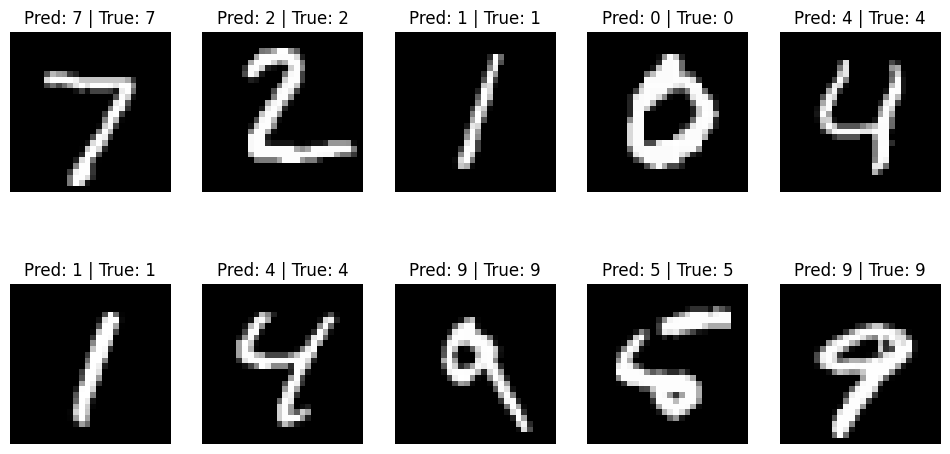

In [ ]:
import matplotlib.pyplot as plt

def show_predictions(x, y_true, y_pred, num_images=10):
  plt.figure(figsize=(12, 6))

  for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(x[i].reshape(28, 28), cmap='gray')
    plt.title(f'Pred: {y_pred[i]} | True: {y_true[i]}')
    plt.axis('off')

  plt.show()

# call function
show_predictions(X_test, y_test, predicted_labels, num_images=10)

Dropout -> used as a regularization technique to avoid the issue of overfitting and in this technique random neurons are dropped in each layer.

In [ ]:
model_v1 = models.Sequential([
    layers.Dense(256, input_shape=(784,)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_v1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model_v1.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8962 - loss: 0.3522 - val_accuracy: 0.9672 - val_loss: 0.1088
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9459 - loss: 0.1801 - val_accuracy: 0.9733 - val_loss: 0.0867
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9565 - loss: 0.1393 - val_accuracy: 0.9765 - val_loss: 0.0761
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9630 - loss: 0.1175 - val_accuracy: 0.9780 - val_loss: 0.0687
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9677 - loss: 0.1005 - val_accuracy: 0.9807 - val_loss: 0.0609
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9708 - loss: 0.0936 - val_accuracy: 0.9825 - val_loss: 0.0610
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9735 - loss: 0.0843 - val_accuracy: 0.9825 - val_loss: 0.0585
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9750 - loss: 0.0783 - val_accuracy: 0.

In [ ]:
predictions = model_v1.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[7 2 1 ... 4 5 6]


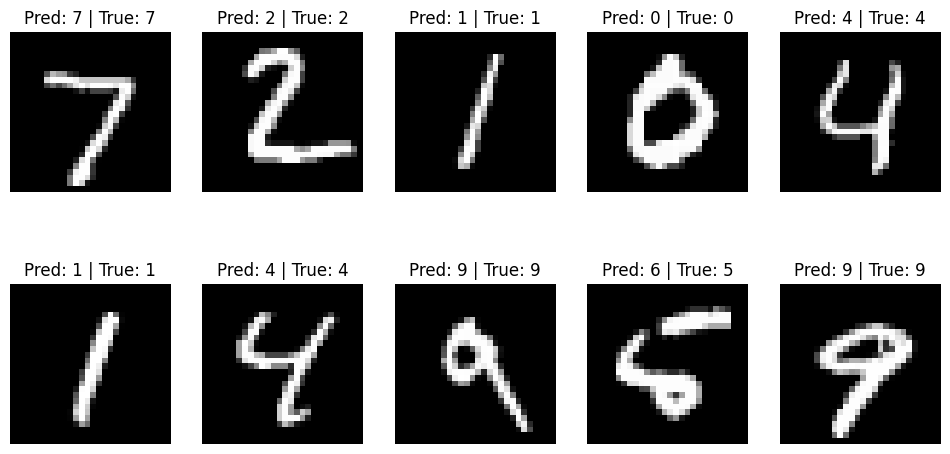

In [ ]:
import matplotlib.pyplot as plt

def show_predictions(x, y_true, y_pred, num_images=10):
  plt.figure(figsize=(12, 6))

  for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(x[i].reshape(28, 28), cmap='gray')
    plt.title(f'Pred: {y_pred[i]} | True: {y_true[i]}')
    plt.axis('off')

  plt.show()

# call function
show_predictions(X_test, y_test, predicted_labels, num_images=10)

### Code Summary

This notebook demonstrates the process of building and training a neural network for image classification using the MNIST dataset, with a focus on **Batch Normalization** and **Dropout** layers.

1.  **Import Libraries**: Essential libraries like TensorFlow, Keras layers, and NumPy are imported.
2.  **Load and Preprocess Data**: The MNIST dataset (handwritten digits) is loaded. The pixel values are normalized to a 0-1 range, and the 28x28 images are flattened into 784-element vectors.
3.  **Build Model with Batch Normalization (Model 1)**:
    *   A sequential Keras model is constructed with Dense layers, Batch Normalization, and ReLU activation functions. Batch Normalization helps in stabilizing and accelerating the training process.
4.  **Compile and Train Model 1**:
    *   The model is compiled with the Adam optimizer, `sparse_categorical_crossentropy` loss (suitable for integer labels), and `accuracy` as a metric.
    *   It is then trained for 10 epochs on the training data, with 10% used for validation.
5.  **Evaluate and Visualize Model 1 Predictions**:
    *   Predictions are made on the test set.
    *   A function `show_predictions` is defined and used to display a sample of 10 test images along with their true labels and the model's predicted labels.
6.  **Build Model with Batch Normalization and Dropout (Model 2 - `model_v1`)**:
    *   A second sequential Keras model (`model_v1`) is built, identical to the first but with the addition of `Dropout` layers after each ReLU activation. Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting.
7.  **Compile and Train Model 2**:
    *   `model_v1` is compiled and trained using the same parameters as Model 1.
8.  **Evaluate and Visualize Model 2 Predictions**:
    *   Predictions are made on the test set using `model_v1`.
    *   The `show_predictions` function is reused to visualize a sample of predictions from this model.